<a href="https://colab.research.google.com/github/Theflawlessone/Face_Detection/blob/main/notebooks/2_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Imports
---

In [36]:
import os, tarfile, re, glob, random
from google.colab import userdata
from collections import defaultdict
from pathlib import Path
import pickle
import pandas as pd
import numpy as np
from PIL import Image
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.models as models
import seaborn as sns

from tqdm import tqdm
from PIL import Image

In [37]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

In [63]:
if 'COLAB_RELEASE_TAG' in os.environ:
    os.chdir('/content/Face_Detection')
else:
    os.chdir(Path.cwd().parent)

BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "data"
CROPPED_DIR = BASE_DIR / "data" / "cropped"
MODEL_DIR = BASE_DIR / "models"

MODEL_DIR.mkdir(exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)
CROPPED_DIR.mkdir(parents=True, exist_ok=True)

In [39]:
df_cropped = pd.read_csv(DATA_DIR / "metadata.csv").iloc[:, :-1]
df_cropped.head()

,age,gender,race,path,age_group,gender_str,race_str,age_group_str
0,100,1,0,data/cropped/100_1_0_20170110183726390.jpg,4,Female,White,Senior (60+)
1,100,1,2,data/cropped/100_1_2_20170105174847679.jpg,4,Female,Asian,Senior (60+)
2,100,1,2,data/cropped/100_1_2_20170110182836729.jpg,4,Female,Asian,Senior (60+)
3,101,1,2,data/cropped/101_1_2_20170105174739309.jpg,4,Female,Asian,Senior (60+)
4,10,0,0,data/cropped/10_0_0_20161220222308131.jpg,0,Male,White,Child (0–12)


In [72]:
gender_map = {0: "Male", 1: "Female"}
race_map   = {0: "White", 1: "Black", 2: "Asian", 3: "Indian", 4: "Other"}
age_group_map = {
    0: "Child (0–12)",
    1: "Teen (13–19)",
    2: "Young Adult (20–39)",
    3: "Middle-Aged (40–59)",
    4: "Senior (60+)",
}

In [40]:
# splits
train_df, temp_df = train_test_split(
    df_cropped,
    test_size=0.3,
    random_state=SEED,
    stratify=df_cropped["age_group"],
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=SEED,
    stratify=temp_df["age_group"],
)

print(len(train_df), len(val_df), len(test_df))

16853 3611 3612


### Push pickle files to repo:

In [ ]:
PICKLE_DIR = "/content/Face_Detection/pickle_files"
os.makedirs(PICKLE_DIR, exist_ok=True)

In [ ]:
with open(os.path.join(PICKLE_DIR, "df_cropped.pkl"), "wb") as f:
    pickle.dump(df_cropped, f)

with open(os.path.join(PICKLE_DIR, "train_df.pkl"), "wb") as f:
    pickle.dump(train_df, f)

with open(os.path.join(PICKLE_DIR, "val_df.pkl"), "wb") as f:
    pickle.dump(val_df, f)

with open(os.path.join(PICKLE_DIR, "test_df.pkl"), "wb") as f:
    pickle.dump(test_df, f)

### Load pickles from repo:

In [ ]:
# START HERE
import requests
GITHUB_BASE = "https://raw.githubusercontent.com/Theflawlessone/Face_Detection/main/pickle_files"

def load_pickle_from_github(filename):
    url = f"{GITHUB_BASE}/{filename}"
    response = requests.get(url)
    response.raise_for_status()  # catch 404 errors
    return pickle.loads(response.content)

In [ ]:
train_df = load_pickle_from_github("train_df.pkl")
val_df   = load_pickle_from_github("val_df.pkl")
test_df  = load_pickle_from_github("test_df.pkl")
df_cropped = load_pickle_from_github("df_cropped.pkl")

### Transform + dataset class:

In [41]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

IMG_SIZE = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(),
    T.ColorJitter(brightness=0.15, contrast=0.15),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

test_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

Using device: cuda


In [42]:
class UTKFaceDataset(Dataset):
    def __init__(self, df, transform=None, mode="age_group"):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.mode = mode

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.loc[idx]
        img = Image.open(row["path"]).convert("RGB")
        if self.transform:
            img = self.transform(img)

        age = torch.tensor(row["age"], dtype=torch.float32)
        age_group = torch.tensor(row["age_group"], dtype=torch.long)
        gender = torch.tensor(row["gender"], dtype=torch.long)
        race = torch.tensor(row["race"], dtype=torch.long)

        if self.mode == "regression":
            return img, age, gender, race
        elif self.mode == "age_group":
            return img, age_group, gender, race

### Dataloaders:

In [54]:
BATCH_SIZE = 32

In [55]:
# CLS loaders
train_ds_cls = UTKFaceDataset(train_df, transform=train_transform, mode="age_group")
val_ds_cls   = UTKFaceDataset(val_df,   transform=test_transform, mode="age_group")
test_ds_cls  = UTKFaceDataset(test_df,  transform=test_transform, mode="age_group")

train_loader = DataLoader(train_ds_cls, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=(device.type == "cuda"))
val_loader   = DataLoader(val_ds_cls,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=(device.type == "cuda"))
test_loader  = DataLoader(test_ds_cls,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=(device.type == "cuda"))

In [56]:
# REG loaders
train_ds_reg = UTKFaceDataset(train_df, transform=train_transform, mode="regression")
val_ds_reg   = UTKFaceDataset(val_df,   transform=test_transform, mode="regression")
test_ds_reg  = UTKFaceDataset(test_df,  transform=test_transform, mode="regression")

train_loader_reg = DataLoader(train_ds_reg, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=2, pin_memory=(device.type == "cuda"))
val_loader_reg   = DataLoader(val_ds_reg,   batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=2, pin_memory=(device.type == "cuda"))
test_loader_reg  = DataLoader(test_ds_reg,  batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=2, pin_memory=(device.type == "cuda"))

### Models:

In [57]:
NUM_AGE_GROUPS = 5

In [58]:
# CLS
class AgeGroupResNet18(nn.Module):
    def __init__(self, num_age_groups=NUM_AGE_GROUPS):
        super().__init__()
        self.base = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        in_feats = self.base.fc.in_features
        self.base.fc = nn.Linear(in_feats, num_age_groups)

    def forward(self, x):
        return self.base(x)

In [59]:
# REG
class ResNetAgeReg(nn.Module):
    def __init__(self):
        super().__init__()
        self.base = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        in_feats = self.base.fc.in_features
        self.base.fc = nn.Linear(in_feats, 1)

    def forward(self, x):
        out = self.base(x)  # [B, 1]
        return out.squeeze(1)

## Training/loading
---

#### Classification:

In [60]:
model_cls = AgeGroupResNet18().to(device)

criterion_cls = nn.CrossEntropyLoss()
optimizer_cls = torch.optim.Adam(model_cls.parameters(), lr=1e-4, weight_decay=1e-4)

In [61]:
def train_one_epoch(model, loader, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for imgs, age_group, gender, race in loader:
        imgs = imgs.to(device)
        age_group = age_group.to(device)

        optimizer.zero_grad()
        logits = model(imgs)           # [B, num_age_groups]
        loss = criterion_cls(logits, age_group)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)

        _, preds = logits.max(1)
        correct += (preds == age_group).sum().item()
        total += imgs.size(0)

    avg_loss = running_loss / total
    acc = correct / total
    return avg_loss, acc


@torch.no_grad()
def eval_one_epoch(model, loader, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    for imgs, age_group, gender, race in loader:
        imgs = imgs.to(device)
        age_group = age_group.to(device)

        logits = model(imgs)
        loss = criterion_cls(logits, age_group)

        running_loss += loss.item() * imgs.size(0)

        _, preds = logits.max(1)
        correct += (preds == age_group).sum().item()
        total += imgs.size(0)

    avg_loss = running_loss / total
    acc = correct / total
    return avg_loss, acc

In [62]:
EPOCHS = 10
best_val_acc = 0.0

for epoch in tqdm(range(1, EPOCHS + 1)):
    train_loss, train_acc = train_one_epoch(model_cls, train_loader, optimizer_cls, device)
    val_loss, val_acc = eval_one_epoch(model_cls, val_loader, device)

    print(f"Epoch {epoch:02d}:")
    print(f"Train - loss: {train_loss:.4f}, acc: {train_acc:.4f}")
    print(f"Val - loss: {val_loss:.4f}, acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model_cls.state_dict(), MODEL_DIR / "best_classification_resnet18.pt")
        print("Saved new best model.")

 10%|█         | 1/10 [00:30<04:32, 30.33s/it]

Epoch 01:
Train - loss: 0.6672, acc: 0.7398
Val - loss: 0.5510, acc: 0.7906
Saved new best model.


 20%|██        | 2/10 [01:01<04:08, 31.04s/it]

Epoch 02:
Train - loss: 0.4924, acc: 0.8080
Val - loss: 0.5392, acc: 0.7937
Saved new best model.


 30%|███       | 3/10 [01:34<03:42, 31.75s/it]

...

Epoch 08:
Train - loss: 0.1396, acc: 0.9542
Val - loss: 0.7799, acc: 0.7746


 90%|█████████ | 9/10 [04:47<00:31, 32.00s/it]

Epoch 09:
Train - loss: 0.1155, acc: 0.9595
Val - loss: 0.7561, acc: 0.7859


100%|██████████| 10/10 [05:20<00:00, 32.01s/it]

Epoch 10:
Train - loss: 0.0901, acc: 0.9704
Val - loss: 0.8292, acc: 0.7917


#### Regression:

In [65]:
model_reg = ResNetAgeReg().to(device)

reg_criterion = nn.MSELoss()
optimizer_reg = torch.optim.Adam(model_reg.parameters(), lr=1e-4, weight_decay=1e-4)

In [66]:
def train_one_epoch_reg(model, loader, optimizer, device):
    model.train()
    running_loss = 0.0
    running_mae = 0.0
    total = 0

    for imgs, age, gender, race in loader:   #tqdm(loader, desc="Train batches", leave=False)
        imgs = imgs.to(device)
        age = age.to(device)

        optimizer.zero_grad()
        preds = model(imgs)

        loss = reg_criterion(preds, age)
        loss.backward()
        optimizer.step()

        batch_size = imgs.size(0)
        running_loss += loss.item() * batch_size
        running_mae += (preds.detach() - age).abs().sum().item()
        total += batch_size

    avg_loss = running_loss / total
    avg_mae = running_mae / total
    return avg_loss, avg_mae

@torch.no_grad()
def eval_one_epoch_reg(model, loader, device):
  model.eval()
  running_loss = 0.0
  running_mae = 0.0
  total = 0

  for imgs, age, gender, race in loader:
    imgs = imgs.to(device)
    age = age.to(device)

    preds = model(imgs)
    loss = reg_criterion(preds, age)

    batch_size = imgs.size(0)
    running_loss += loss.item() * batch_size
    running_mae += (preds - age).abs().sum().item()
    total += batch_size

  avg_loss = running_loss / total
  avg_mae = running_mae / total

  return avg_loss, avg_mae

In [68]:
EPOCHS = 10
best_val_mae = float("inf")

for epoch in tqdm(range(1, EPOCHS + 1)):
  train_mse, train_mae = train_one_epoch_reg(model_reg, train_loader_reg, optimizer_reg, device)
  val_mse, val_mae = eval_one_epoch_reg(model_reg, val_loader_reg, device)

  print(f' Epoch {epoch:02d}')
  print(f' Train - MSE {train_mse:.4f}, MAE: {train_mae:.4f}')
  print(f' Val - MSE {val_mse:.4f}, MAE: {val_mae:.4f}')

  if val_mae < best_val_mae:
    best_val_mae = val_mae
    torch.save(model_reg.state_dict(), MODEL_DIR / "best_age_regressor_resnet18.pt")
    print('Saved new best regression model.')

 10%|█         | 1/10 [00:30<04:35, 30.63s/it]

 Epoch 01
 Train - MSE 66.6490, MAE: 5.9491
 Val - MSE 60.3869, MAE: 5.4999
Saved new best regression model.


 20%|██        | 2/10 [01:00<04:03, 30.41s/it]

 Epoch 02
 Train - MSE 53.1985, MAE: 5.3397
 Val - MSE 56.9971, MAE: 5.2620
Saved new best regression model.


 30%|███       | 3/10 [01:31<03:32, 30.36s/it]

...

 Epoch 08
 Train - MSE 19.4618, MAE: 3.2541
 Val - MSE 52.2843, MAE: 5.0694
Saved new best regression model.


 90%|█████████ | 9/10 [04:32<00:30, 30.20s/it]

 Epoch 09
 Train - MSE 17.2113, MAE: 3.0704
 Val - MSE 53.1654, MAE: 5.0902


100%|██████████| 10/10 [05:02<00:00, 30.29s/it]

 Epoch 10
 Train - MSE 15.5571, MAE: 2.9344
 Val - MSE 50.6408, MAE: 5.0080
Saved new best regression model.


## Load best model and evaluate
---

#### Classification model:

In [69]:
# classification
model_cls = AgeGroupResNet18().to(device)
model_cls.load_state_dict(torch.load(
    MODEL_DIR / "best_classification_resnet18.pt",
    map_location=device
))
model_cls.eval()

test_loss, test_acc = eval_one_epoch(model_cls, test_loader, device)
print(f"Test - loss: {test_loss:.4f}, acc: {test_acc:.4f}")

Test - loss: 0.5413, acc: 0.8029


In [70]:
# check bias and fairness
@torch.no_grad()
def eval_by_group(model, loader, device):
    model.eval()

    total = 0
    correct = 0

    # stats before mapping (keys are ints)
    gender_correct = defaultdict(int)
    gender_total   = defaultdict(int)

    race_correct = defaultdict(int)
    race_total   = defaultdict(int)

    agegroup_correct = defaultdict(int)
    agegroup_total   = defaultdict(int)

    for imgs, age_group, gender, race in loader:
        imgs = imgs.to(device)
        age_group = age_group.to(device)

        logits = model(imgs)
        _, preds = logits.max(1)

        total += imgs.size(0)
        correct += (preds == age_group).sum().item()

        # move meta labels to CPU
        g_np = gender.cpu().numpy()
        r_np = race.cpu().numpy()
        t_np = age_group.cpu().numpy()
        p_np = preds.cpu().numpy()

        for g, r, t, p in zip(g_np, r_np, t_np, p_np):
            gender_total[g] += 1
            race_total[r] += 1
            agegroup_total[t] += 1

            if p == t:
                gender_correct[g] += 1
                race_correct[r] += 1
                agegroup_correct[t] += 1

    # overall
    overall_acc = correct / total

    # map int keys -> strings
    gender_acc = {
        gender_map[g]: gender_correct[g] / gender_total[g]
        for g in gender_total
    }

    race_acc = {
        race_map[r]: race_correct[r] / race_total[r]
        for r in race_total
    }

    agegroup_acc = {
        age_group_map[a]: agegroup_correct[a] / agegroup_total[a]
        for a in agegroup_total
    }

    return overall_acc, gender_acc, race_acc, agegroup_acc


In [73]:
overall_acc, gender_acc, race_acc, agegroup_acc = eval_by_group(
    model_cls, test_loader, device
)

print("----Bias & Fairness Evaluation----")
print("Overall Accuracy:", round(overall_acc, 4))
print("\nAccuracy by Gender:")
for k, v in gender_acc.items():
    print(f"  {k}: {v:.4f}")

print("\nAccuracy by Race:")
for k, v in race_acc.items():
    print(f"  {k}: {v:.4f}")

print("\nAccuracy by Age Group (True Labels):")
for k, v in agegroup_acc.items():
    print(f"  {k}: {v:.4f}")

----Bias & Fairness Evaluation----
Overall Accuracy: 0.8029

Accuracy by Gender:
  Female: 0.8243
  Male: 0.7833

Accuracy by Race:
  Black: 0.8083
  Indian: 0.8094
  Other: 0.8918
  White: 0.7521
  Asian: 0.8921

Accuracy by Age Group (True Labels):
  Young Adult (20–39): 0.9177
  Child (0–12): 0.9365
  Middle-Aged (40–59): 0.5681
  Teen (13–19): 0.4722
  Senior (60+): 0.6602


#### Regression:

In [74]:
model_reg = ResNetAgeReg().to(device)
model_reg.load_state_dict(torch.load(
    MODEL_DIR / "best_age_regressor_resnet18.pt",
    map_location=device
))
model_reg.eval()

test_mse, test_mae = eval_one_epoch_reg(model_reg, test_loader_reg, device)
print(f"Test - MSE: {test_mse:.4f}, MAE: {test_mae:.4f}")

Test - MSE: 48.6894, MAE: 4.8379


In [75]:
# check bias and fairness
@torch.no_grad()
def eval_regression_by_group(model, loader, device, gender_map, race_map, age_group_map=None):
    model.eval()

    total=0
    abs_error_sum=0.0

    gender_abs_error=defaultdict(float)
    gender_total=defaultdict(int)

    race_abs_error=defaultdict(float)
    race_total=defaultdict(int)

    for imgs, age, gender, race in loader:
        imgs=imgs.to(device)
        age=age.to(device)

        preds=model(imgs)  # [B]
        abs_err=(preds - age).abs()  # [B]

        total += imgs.size(0)
        abs_error_sum += abs_err.sum().item()

        g_np=gender.cpu().numpy()
        r_np=race.cpu().numpy()
        err_np=abs_err.cpu().numpy()

        for g, r, e in zip(g_np, r_np, err_np):
            gender_abs_error[g] += float(e)
            gender_total[g] += 1
            race_abs_error[r] += float(e)
            race_total[r] += 1

    overall_mae = abs_error_sum / total

    gender_mae = {
        gender_map[g]: gender_abs_error[g] / gender_total[g]
        for g in gender_total
    }

    race_mae = {
        race_map[r]: race_abs_error[r] / race_total[r]
        for r in race_total
    }

    return overall_mae, gender_mae, race_mae

In [76]:
overall_mae, gender_mae, race_mae = eval_regression_by_group(
    model_reg, test_loader_reg, device,
    gender_map=gender_map,
    race_map=race_map
)

print("Overall MAE (years):", overall_mae)
print("\nMAE by Gender:")
for k, v in gender_mae.items():
    print(f"  {k}: {v:.2f}")

print("\nMAE by Race:")
for k, v in race_mae.items():
    print(f"  {k}: {v:.2f}")

Overall MAE (years): 4.837900402538008

MAE by Gender:
  Female: 4.73
  Male: 4.94

MAE by Race:
  Black: 5.50
  Indian: 4.43
  Other: 3.67
  White: 5.39
  Asian: 3.38


In [77]:
# heat map for regression
@torch.no_grad()
def mae_by_gender_race(model, loader, device, gender_map, race_map):
    model.eval()

    # accumulate abs error and counts per (gender, race)
    err_sum = defaultdict(float)
    count   = defaultdict(int)

    for imgs, age, gender, race in loader:
        imgs = imgs.to(device)
        age  = age.to(device)

        preds = model(imgs)          # [B]
        abs_err = (preds - age).abs().cpu().numpy()  # [B]

        g_np = gender.cpu().numpy()
        r_np = race.cpu().numpy()

        for g, r, e in zip(g_np, r_np, abs_err):
            err_sum[(g, r)] += float(e)
            count[(g, r)]   += 1

    # build matrix indexed by gender (rows) and race (cols)
    genders = list(gender_map.keys())
    races   = list(race_map.keys())

    data = np.full((len(genders), len(races)), np.nan, dtype=float)

    for i, g in enumerate(genders):
        for j, r in enumerate(races):
            if count[(g, r)] > 0:
                data[i, j] = err_sum[(g, r)] / count[(g, r)]  # MAE

    # nice DataFrame with labels
    df_mae = pd.DataFrame(
        data,
        index=[gender_map[g] for g in genders],
        columns=[race_map[r] for r in races],
    )
    return df_mae

In [78]:
df_heat = mae_by_gender_race(model_reg, test_loader_reg, device, gender_map, race_map)
print(df_heat)

           White     Black     Asian    Indian     Other
Male    5.241755  5.637687  3.506508  4.656249  4.268399
Female  5.567369  5.344384  3.286179  4.124331  3.161583


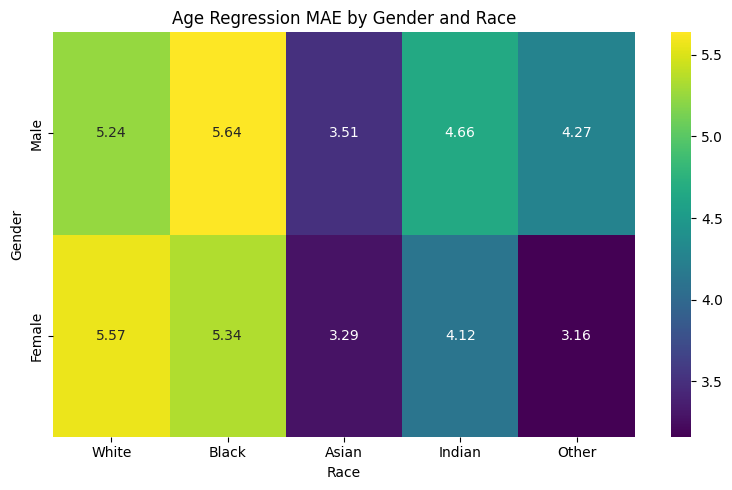

In [79]:
plt.figure(figsize=(8, 5))
sns.heatmap(
    df_heat,
    annot=True,
    fmt=".2f",
    cmap="viridis",  # or "magma", "coolwarm", etc.
)
plt.title("Age Regression MAE by Gender and Race")
plt.ylabel("Gender")
plt.xlabel("Race")
plt.tight_layout()
plt.show()